# ipynb/loc_compare.ipynb - 定位对比 / Localization comparison

## 项目背景 / Background
定位对比
Localization comparison

## 功能模块 / Modules
- 多模型定位结果对比
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: inference_*.py、ipynb/loc_compare_*.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



Warning message:
“package ‘showtext’ was built under R version 4.3.3”
Loading required package: sysfonts

Warning message:
“package ‘sysfonts’ was built under R version 4.3.3”
Loading required package: showtextdb

Warning message:
“package ‘showtextdb’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘scales’ was built under R version 4.3.3”


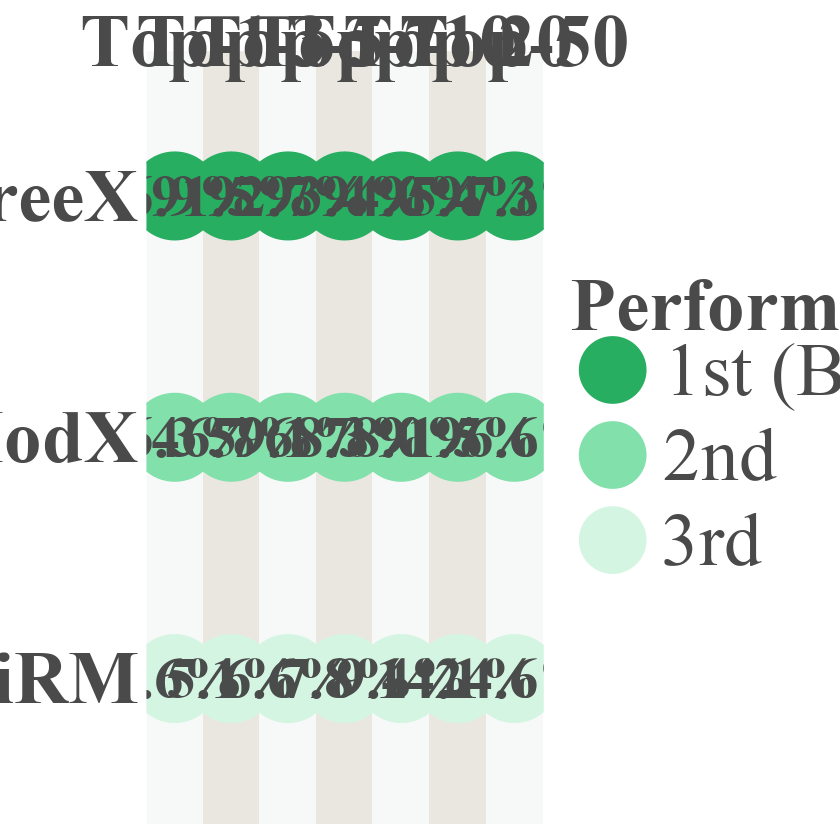

In [1]:
# 1. 安装并加载字体管理包
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)

# 2. 注册Times New Roman (如路径不同请自行调整)
tryCatch({
  font_add("Times New Roman", 
           regular = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf", 
           bold = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf")
  showtext_auto()
}, error = function(e) message("字体加载失败，使用默认字体"))

showtext_opts(dpi = 300)

# --- 1. 数据读取与计算平均值 ---
file_list <- list(
  "ModX" = "data/modx_loc.csv",
  "MultiRM" = "data/multirm_loc.csv",
  "TreeX" = "data/rgcnformer_loc.csv"
)

# 这里的名称必须与 CSV 中的原始列名完全一致
metric_levels <- c("Top-1", "Top-3", "Top-5", "Top-7", "Top-10", "Top-20", "Top-50")

# 自动读取并计算均值
df_list <- lapply(names(file_list), function(mname) {
  # 关键点：使用 check.names = FALSE 防止 Top-1 变成 Top.1
  read.csv(file_list[[mname]], check.names = FALSE) %>%
    summarise(across(all_of(metric_levels), \(x) mean(x, na.rm = TRUE))) %>%
    mutate(Model = mname)
})

# 合并原始计算数据
raw_combined <- bind_rows(df_list)

# --- 2. 计算综合平均值并对模型排序 ---
# 计算每个模型在所有 Top 指标上的总均值，并据此对 Model 排序
model_order_data <- raw_combined %>%
  rowwise() %>%
  mutate(Overall_Score = mean(c_across(all_of(metric_levels)))) %>%
  arrange(Overall_Score) # 升序排列，这样在 Factor 中性能最好的模型会排在最后（即绘图的最上方）

ordered_models <- model_order_data$Model

# 转换为绘图格式
plot_data <- raw_combined %>%
  pivot_longer(cols = all_of(metric_levels), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric = factor(Metric, levels = metric_levels),
    Model = factor(Model, levels = ordered_models) 
  ) %>%
  # 计算排名：在每个指标内部，Value 最大的排名为 1
  group_by(Metric) %>%
  mutate(Rank = rank(-Value, ties.method = "first")) %>% 
  ungroup() %>%
  mutate(Rank_Factor = factor(Rank, levels = c(1, 2, 3), labels = c("1st (Best)", "2nd", "3rd")))

# --- 3. 准备背景数据 ---
bg_colors <- c("#F7F9F9", "#EAE7E1")
bg_rects <- data.frame(
  Metric = factor(metric_levels, levels = metric_levels),
  xmin = seq_along(metric_levels) - 0.5,
  xmax = seq_along(metric_levels) + 0.5,
  fill = rep(bg_colors, length.out = length(metric_levels))
)

# --- 4. 定义颜色 ---
rank_palette <- c(
  "1st (Best)" = "#27AE60",  # 翡翠绿
  "2nd"        = "#82E0AA",  # 中浅绿
  "3rd"        = "#D5F5E3"   # 极浅绿
)

# --- 5. 绘图 ---
p1 <- ggplot() +
  # A. 绘制列背景
  geom_rect(data = bg_rects, aes(xmin = xmin, xmax = xmax, ymin = -Inf, ymax = Inf, fill = fill),
            alpha = 1, show.legend = FALSE) +
  scale_fill_identity() + 
  
  # B. 绘制圆圈：由于 MultiRM 数值极低，设置 limits 为 0-1 确保显示
  geom_point(data = plot_data, aes(x = Metric, y = Model, size = Value, color = Rank_Factor)) +
  
  # C. 绘制数值文本 (以百分比显示)
  geom_text(data = plot_data, aes(x = Metric, y = Model, 
                                 label = sprintf("%.1f%%", Value * 100)), 
            size = 5, fontface = "bold", family = "Times New Roman", color = "#4A4B4B") +
  
  # 颜色和尺寸映射
  scale_color_manual(name = "Performance Rank", values = rank_palette) +
  scale_size_continuous(
    range = c(24, 24),
    limits = c(0, 1),
    guide = "none"
  ) +
  
  # 坐标轴和主题
  scale_x_discrete(position = "top", expand = c(0, 0)) + 
  scale_y_discrete(expand = expansion(add = c(0.6, 0.6))) +
  theme_minimal() +
  theme(
    text = element_text(family = "Times New Roman"),
    axis.text.x = element_text(size = 18, face = "bold", color = "#4A4A4A"),
    axis.text.y = element_text(size = 18, face = "bold", color = "#4A4A4A"),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 18, face = "bold", color = "#4A4A4A"),
    legend.text = element_text(size = 18, color = "#4A4A4A"),
    plot.margin = margin(10, 10, 10, 10)
  ) +
  
  guides(
    color = guide_legend(
      override.aes = list(size = 18),
      label.theme = element_text(size = 18),
      order = 1
    )
  )

# --- 6. 保存 ---
ggsave("png3/model_recall_comparison.pdf", p1, width = 10, height = 3, dpi = 300)
print(p1)